In [1]:
import sys
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để import được thư viện trong folder src
sys.path.append('../src') 
from cluster_library import RuleBasedCustomerClusterer

# 1. Load dữ liệu giao dịch đã làm sạch
# Lưu ý: Dựa vào ảnh của bạn, file này nằm trong data/processed
df_trans = pd.read_csv('../data/processed/cleaned_uk_data.csv')

# 2. Load luật kết hợp (Bạn đang có cả Apriori và FP-Growth, dùng FP-Growth cho xịn)
df_rules = pd.read_csv('../data/processed/rules_fpgrowth_filtered.csv')

print("Data Transaction:", df_trans.shape)
print("Data Rules:", df_rules.shape)

Data Transaction: (485123, 11)
Data Rules: (21, 17)


In [2]:
clusterer = RuleBasedCustomerClusterer()

# Lọc lấy 30 luật có chỉ số Lift cao nhất
# Lift cao thể hiện mối quan hệ mua kèm mạnh mẽ, không ngẫu nhiên
clusterer.load_top_rules(df_rules, top_k=30, metric='lift')

# Xây dựng ma trận đặc trưng (Khách hàng x Luật)
# Lưu ý: Kiểm tra tên cột CustomerID và StockCode trong df_trans của bạn. 
# Nếu cleaned_uk_data.csv dùng tên khác thì sửa lại ở đây.
df_features = clusterer.build_customer_feature_matrix(
    df_trans, 
    customer_col='CustomerID', 
    item_col='StockCode'
)

df_features.head()

✅ Đã load 21 luật dựa trên lift cao nhất.
⏳ Đang tạo đặc trưng từ luật cho từng khách hàng (bước này tốn chút thời gian)...
✅ Đã tạo xong vector đặc trưng. Shape: (3921, 21)


,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_11,Rule_12,Rule_13,Rule_14,Rule_15,Rule_16,Rule_17,Rule_18,Rule_19,Rule_20
000nan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
012346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
012747,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
012748,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
012749,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Tính toán RFM từ dữ liệu giao dịch
df_trans['InvoiceDate'] = pd.to_datetime(df_trans['InvoiceDate'])
last_date = df_trans['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_trans.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (last_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                              # Frequency
    'UnitPrice': 'sum'                                   # Monetary (Giả định UnitPrice là doanh thu nếu ko có cột Total)
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'UnitPrice': 'Monetary'})

# Ghép RFM vào bộ dữ liệu (trọng số 2.0 để ưu tiên RFM hơn Rules một chút)
clusterer.add_rfm_features(rfm, weight=2.0)

⏳ Đang ghép dữ liệu RFM...
✅ Đã ghép thêm RFM. Shape mới: (3921, 24)


⏳ Đang chạy thử nghiệm K từ 2 đến 8...
   K=2 -> Silhouette=0.7376
   K=3 -> Silhouette=0.6737
   K=4 -> Silhouette=0.6118
   K=5 -> Silhouette=0.6108
   K=6 -> Silhouette=0.5927
   K=7 -> Silhouette=0.5954
   K=8 -> Silhouette=0.5532


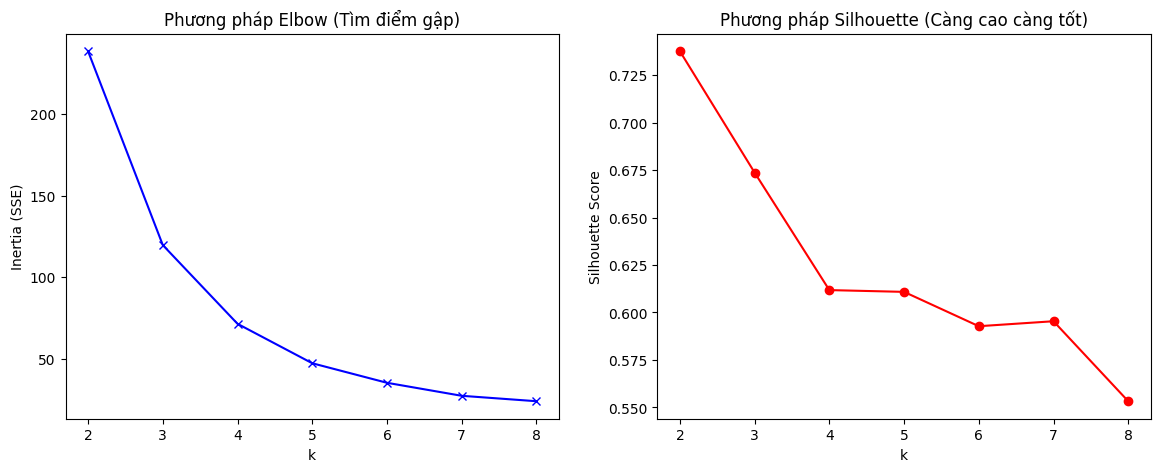

In [4]:
# Chạy thử K từ 2 đến 8 để tìm số cụm tối ưu
# Nhìn vào biểu đồ Silhouette (càng cao càng tốt) để chọn K
clusterer.choose_k_elbow_silhouette(k_range=range(2, 9))

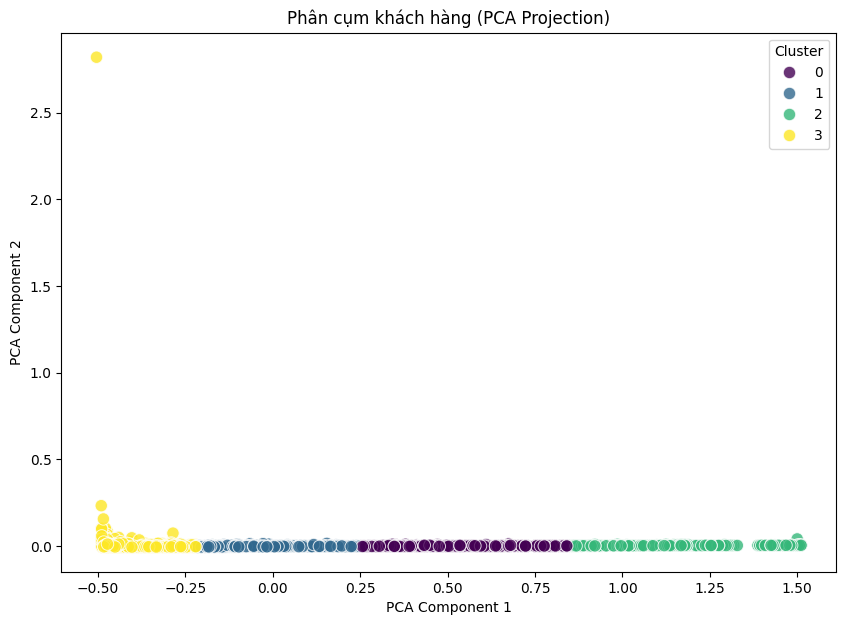

Hồ sơ trung bình của các cụm:


,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_14,Rule_15,Rule_16,Rule_17,Rule_18,Rule_19,Rule_20,Recency,Frequency,Monetary
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.028642,0.001279,0.000281
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441104,0.002449,0.000391
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.646840,0.000528,0.000200
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.102180,0.008728,0.001995


Số lượng khách hàng mỗi cụm:
Cluster
3    1983
1     940
0     556
2     442
Name: count, dtype: int64


In [5]:
# Giả sử bạn chọn K=3 hoặc K=4 sau khi xem biểu đồ trên
final_k = 4 

# Chạy phân cụm
results = clusterer.run_clustering(k=final_k)

# Vẽ biểu đồ 2D
clusterer.visualize_2d()

# Xem hồ sơ cụm (Profiling) để viết báo cáo
print("Hồ sơ trung bình của các cụm:")
display(clusterer.profile_clusters())

print("Số lượng khách hàng mỗi cụm:")
print(results['Cluster'].value_counts())

>>> BẢNG THỐNG KÊ TRUNG BÌNH CÁC CỤM (Dùng để so sánh):


,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_14,Rule_15,Rule_16,Rule_17,Rule_18,Rule_19,Rule_20,Recency,Frequency,Monetary
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.028642,0.001279,0.000281
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441104,0.002449,0.000391
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.646840,0.000528,0.000200
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.102180,0.008728,0.001995


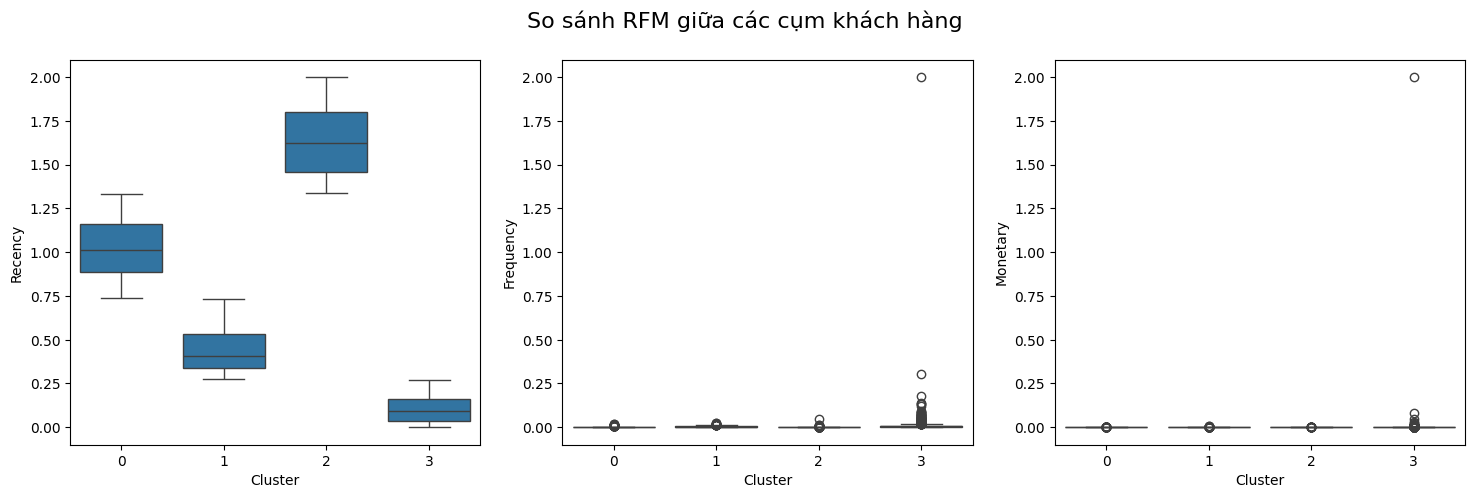

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
# Tính giá trị trung bình của các đặc trưng theo từng cụm
cluster_summary = results.groupby('Cluster').mean()

# Nếu bạn có cột RFM, nó sẽ hiện Recency, Frequency, Monetary trung bình
# Nếu chỉ có Rule, nó sẽ hiện tỉ lệ thỏa mãn luật
print(">>> BẢNG THỐNG KÊ TRUNG BÌNH CÁC CỤM (Dùng để so sánh):")
display(cluster_summary)

# Vẽ biểu đồ Boxplot cho RFM (nếu có) để dễ nhìn sự khác biệt
if 'Monetary' in results.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.boxplot(x='Cluster', y='Recency', data=results, ax=axes[0])
    sns.boxplot(x='Cluster', y='Frequency', data=results, ax=axes[1])
    sns.boxplot(x='Cluster', y='Monetary', data=results, ax=axes[2])
    plt.suptitle('So sánh RFM giữa các cụm khách hàng', fontsize=16)
    plt.show()

In [9]:
def get_top_rules_for_cluster(cluster_id, summary_df, rules_df, top_n=3):
    """
    Hàm tìm top luật phổ biến nhất trong một cụm
    """
    # Lấy dòng dữ liệu của cụm đó
    cluster_data = summary_df.loc[cluster_id]
    
    # Lọc ra các cột là Rule (bỏ qua cột RFM)
    rule_cols = [c for c in cluster_data.index if c.startswith('Rule_')]
    
    # Sắp xếp xem Rule nào có giá trị cao nhất trong cụm này
    top_rules_indices = cluster_data[rule_cols].sort_values(ascending=False).head(top_n).index
    
    print(f"\n ĐẶC TRƯNG CỦA CỤM {cluster_id}:")
    for r_col in top_rules_indices:
        # Lấy index của luật (VD: Rule_10 -> lấy số 10)
        idx = int(r_col.split('_')[1])
        
        # Tra cứu thông tin luật trong bảng rules gốc
        rule_info = rules_df.iloc[idx]
        score = cluster_data[r_col]
        
        if score > 0.01: # Chỉ hiện nếu ít nhất 1% khách trong cụm tuân theo
            print(f"   - {r_col} (Thỏa mãn {score*100:.1f}%): Khách mua {list(rule_info['antecedents'])} ---> Thường mua thêm {list(rule_info['consequents'])}")
        else:
            print(f"   - (Không có luật nào quá nổi bật trong top {top_n})")

# Chạy vòng lặp để in thông tin cho tất cả các cụm
n_clusters = results['Cluster'].nunique()
for k in range(n_clusters):
    get_top_rules_for_cluster(k, cluster_summary, df_rules)


 ĐẶC TRƯNG CỦA CỤM 0:
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)

 ĐẶC TRƯNG CỦA CỤM 1:
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)

 ĐẶC TRƯNG CỦA CỤM 2:
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)

 ĐẶC TRƯNG CỦA CỤM 3:
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)
   - (Không có luật nào quá nổi bật trong top 3)


In [10]:
# Lưu bảng kết quả cuối cùng có nhãn cụm
output_path = '../data/processed/customer_segments.csv'
results.to_csv(output_path)
print(f"✅ Đã lưu kết quả phân cụm vào: {output_path}")

# (Tùy chọn) Lưu bảng thống kê để vẽ biểu đồ báo cáo
cluster_summary.to_csv('../data/processed/cluster_profile_summary.csv')

✅ Đã lưu kết quả phân cụm vào: ../data/processed/customer_segments.csv
